# Phase 4c — Band T native-unit cross-temporal comparison

**LMR MCA–LIA dipole**: is the LIA temperature anomaly field the spatial negative of MCA, or structurally decoupled in some regions? Uses `band_t_native_lmr_lisa.parquet` (from 16b) plus fresh DB load.

**HYDE persistence**: for each 5-arcmin land cell, count non-degenerate epochs (4000 BCE–2000 CE, n=7) in which cropland / grazing fraction > 0. Also maps temporal leading edge (first non-zero epoch). *Adaptation note*: full HYDE LISA was intractable (see BT4B.2); persistence is computed from raw grids (presence/absence), not from HH cluster membership.

Outputs: PNG maps → `output/edop/spatial/`; findings cell → `logs/esda_findings.md` as BT4C.1–N.

In [1]:
# Cell 2 — imports and setup
import ssl, certifi, urllib.request
_ssl_ctx = ssl.create_default_context(cafile=certifi.where())
urllib.request.install_opener(
    urllib.request.build_opener(urllib.request.HTTPSHandler(context=_ssl_ctx))
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import scipy.stats as stats
from pathlib import Path
import sys, time as _time, warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='invalid value encountered')

sys.path.insert(0, '/Users/karlg/Documents/repos/_cedop')
from scripts.shared.db_utils import db_connect

%matplotlib inline

SEED   = 42
OUT_DIR = Path('/Users/karlg/Documents/repos/_cedop/output/edop/spatial')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# LMR epochs (same order as 16b)
LMR_EPOCHS = [
    ('0 CE (early-LMR)',  0,    49),
    ('1000 CE',           950,  1049),
    ('1500 CE',           1450, 1549),
    ('1900 CE',           1850, 1949),
    ('MCA 950\u20131250', 950,  1250),   # index 4
    ('LIA 1450\u20131850', 1450, 1850),  # index 5
]
LMR_SLUGS = ['0ce', '1000ce', '1500ce', '1900ce', 'mca', 'lia']
MCA_IDX, LIA_IDX = 4, 5

# HYDE non-degenerate epochs (step index → label); 8000 BCE / step 2 excluded
HYDE_NONDEG = [
    (6,   '4000 BCE'),
    (9,   '1000 BCE'),
    (10,  '0 CE'),
    (20,  '1000 CE'),
    (25,  '1500 CE'),
    (47,  '1900 CE'),
    (102, '2000 CE'),
]
N_HYDE_EPOCHS = len(HYDE_NONDEG)

LISA_COLORS = {'HH': '#c0392b', 'LL': '#2980b9', 'HL': '#e67e22', 'LH': '#1abc9c', 'NS': '#bdc3c7'}

print('Setup complete. Output:', OUT_DIR)

Setup complete. Output: /Users/karlg/Documents/repos/_cedop/output/edop/spatial


In [2]:
# Cell 3 — load LMR grids from DB (replicates 16b Cell 4)
import netCDF4 as nc

LMR_DIR = Path('/Users/karlg/Documents/repos/_cedop/data/lmr_v2.1')

t0 = _time.time()
ds = nc.Dataset(LMR_DIR / 'pdsi_MCruns_ensemble_mean_LMRv2.1.nc')
time_var = ds.variables['time']
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    times = nc.num2date(time_var[:], time_var.units, has_year_zero=True)
LMR_YEARS = np.array([t.year for t in times])
ds.close()

conn = db_connect()
lmr_df = pd.read_sql(
    'SELECT lat, lon, pdsi, air FROM temporal.lmr_climate ORDER BY lat DESC, lon ASC',
    conn)
conn.close()

pdsi_all = np.array(lmr_df['pdsi'].tolist(), dtype=np.float32)
air_all  = np.array(lmr_df['air'].tolist(),  dtype=np.float32)

lats_lmr = np.sort(lmr_df['lat'].unique())[::-1]   # 91 vals, 90→-90
lons_lmr = np.sort(lmr_df['lon'].unique())          # 180 vals, 0→358
NLAT, NLON = len(lats_lmr), len(lons_lmr)

pdsi_grid = pdsi_all.reshape(NLAT, NLON, len(LMR_YEARS))
air_grid  = air_all.reshape(NLAT, NLON, len(LMR_YEARS))

print(f'LMR loaded in {_time.time()-t0:.1f}s  |  grid {NLAT}x{NLON}  |  years {LMR_YEARS[0]}-{LMR_YEARS[-1]}')

LMR loaded in 18.1s  |  grid 91x180  |  years 0-1998


In [3]:
# Cell 4 — LMR land mask and epoch anomaly slices (replicates 16b Cells 5-6)
t0 = _time.time()

air_full  = np.nanmean(air_grid,  axis=2)
pdsi_full = np.nanmean(pdsi_grid, axis=2)

def epoch_anomaly(grid3d, full_mean, year_lo, year_hi):
    mask = (LMR_YEARS >= year_lo) & (LMR_YEARS <= year_hi)
    return np.nanmean(grid3d[:, :, mask], axis=2) - full_mean

air_epochs, pdsi_epochs = [], []
for label, yr_lo, yr_hi in LMR_EPOCHS:
    air_epochs.append(epoch_anomaly(air_grid,  air_full,  yr_lo, yr_hi))
    pdsi_epochs.append(epoch_anomaly(pdsi_grid, pdsi_full, yr_lo, yr_hi))

# Named MCA / LIA slices for convenience
mca_air  = air_epochs[MCA_IDX]
lia_air  = air_epochs[LIA_IDX]
mca_pdsi = pdsi_epochs[MCA_IDX]
lia_pdsi = pdsi_epochs[LIA_IDX]

# Land mask: L8 basin centroids snapped to 2deg LMR cells
conn = db_connect()
basin_pts = pd.read_sql(
    'SELECT ST_X(ST_Centroid(geom)) AS lon, ST_Y(ST_Centroid(geom)) AS lat FROM public.basin08',
    conn)
conn.close()

basin_lon = basin_pts['lon'].values % 360
basin_lat = basin_pts['lat'].values
snap_row = np.clip(np.round((90 - basin_lat) / 2).astype(int), 0, NLAT - 1)
snap_col = np.clip(np.round(basin_lon       / 2).astype(int), 0, NLON - 1)

land_mask_lmr = np.zeros((NLAT, NLON), dtype=bool)
land_mask_lmr[snap_row, snap_col] = True
lmr_land_rows, lmr_land_cols = np.where(land_mask_lmr)
n_land_lmr = int(land_mask_lmr.sum())

# Lon conversion: 0..358 -> -180..180 for cartopy
lons_lmr_180 = np.where(lons_lmr >= 180, lons_lmr - 360, lons_lmr)
land_lons_180 = lons_lmr_180[lmr_land_cols]
land_lats     = lats_lmr[lmr_land_rows]

print(f'Land mask: {n_land_lmr:,} cells  |  anomalies: {len(air_epochs)} epochs  ({_time.time()-t0:.1f}s)')
print(f'MCA air mean: {np.nanmean(mca_air[land_mask_lmr]):.4f} K  |  LIA air mean: {np.nanmean(lia_air[land_mask_lmr]):.4f} K')

Land mask: 4,924 cells  |  anomalies: 6 epochs  (1.8s)
MCA air mean: -0.0665 K  |  LIA air mean: -0.1303 K


In [4]:
# Cell 5 — load LMR LISA from parquet (produced by 16b)
lisa_df = pd.read_parquet(OUT_DIR / 'band_t_native_lmr_lisa.parquet')
print(f'LISA parquet: {lisa_df.shape}  epochs: {sorted(lisa_df.epoch.unique())}  vars: {lisa_df.variable.unique().tolist()}')

# Filter to MCA and LIA for cross-epoch comparison
def get_lisa(variable, epoch_label):
    sub = lisa_df[(lisa_df.variable == variable) & (lisa_df.epoch == epoch_label)].copy()
    sub = sub.set_index('cell_id')[['lat', 'lon', 'lisa_class', 'p_value']]
    return sub

mca_lisa_air  = get_lisa('temperature', 'MCA 950\u20131250')
lia_lisa_air  = get_lisa('temperature', 'LIA 1450\u20131850')
mca_lisa_pdsi = get_lisa('pdsi',        'MCA 950\u20131250')
lia_lisa_pdsi = get_lisa('pdsi',        'LIA 1450\u20131850')

print(f'MCA temp LISA cells: {len(mca_lisa_air)}  |  LIA temp LISA cells: {len(lia_lisa_air)}')
print('MCA class counts:', mca_lisa_air.lisa_class.value_counts().to_dict())
print('LIA class counts:', lia_lisa_air.lisa_class.value_counts().to_dict())

LISA parquet: (59088, 9)  epochs: ['0 CE (early-LMR)', '1000 CE', '1500 CE', '1900 CE', 'LIA 1450–1850', 'MCA 950–1250']  vars: ['temperature', 'pdsi']
MCA temp LISA cells: 4924  |  LIA temp LISA cells: 4924
MCA class counts: {'NS': 2358, 'HH': 1450, 'LL': 1087, 'HL': 29}
LIA class counts: {'NS': 2679, 'HH': 1431, 'LL': 790, 'HL': 24}


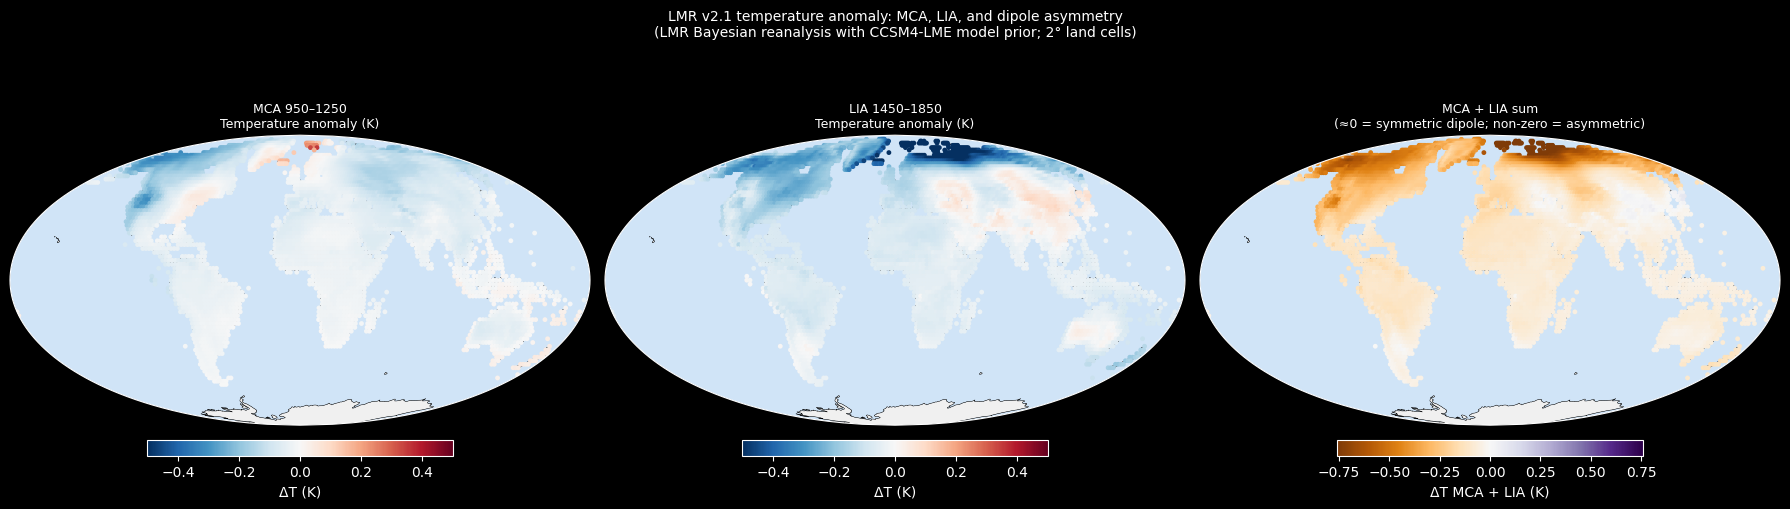

In [6]:
# Cell 6 — LMR temperature dipole maps (Mollweide 3-panel)
# Panel A: MCA anomaly  |  Panel B: LIA anomaly  |  Panel C: MCA+LIA sum (dipole asymmetry)

def lmr_scatter_map(ax, grid_2d, title, vmin, vmax, cmap='RdBu_r', cbar_label=''):
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='#d0e4f7', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3, zorder=1)
    vals = grid_2d[lmr_land_rows, lmr_land_cols]
    sc = ax.scatter(land_lons_180, land_lats,
                    c=vals, cmap=cmap, vmin=vmin, vmax=vmax,
                    s=12, linewidths=0, transform=ccrs.PlateCarree(), zorder=2)
    plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.04, fraction=0.04, label=cbar_label)
    ax.set_title(title, fontsize=9)
    return sc

fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                         subplot_kw={'projection': ccrs.Mollweide()})

# Percentile-based symmetric color scale (avoids outlier cells dominating)
all_land_vals = np.concatenate([mca_air[land_mask_lmr], lia_air[land_mask_lmr]])
abs_max = np.nanpercentile(np.abs(all_land_vals), 98)
abs_max = np.ceil(abs_max * 10) / 10
print(f'MCA/LIA color scale: ±{abs_max:.2f} K  (98th-pct of |anomaly| across both fields)')

lmr_scatter_map(axes[0], mca_air, 'MCA 950–1250\nTemperature anomaly (K)',
                -abs_max, abs_max, cmap='RdBu_r', cbar_label='ΔT (K)')
lmr_scatter_map(axes[1], lia_air, 'LIA 1450–1850\nTemperature anomaly (K)',
                -abs_max, abs_max, cmap='RdBu_r', cbar_label='ΔT (K)')

dipole_sum = mca_air + lia_air
dmax = max(np.abs(np.nanpercentile(dipole_sum[land_mask_lmr], [2, 98])).max(), 0.05)
lmr_scatter_map(axes[2], dipole_sum,
                'MCA + LIA sum\n(≈0 = symmetric dipole; non-zero = asymmetric)',
                -dmax, dmax, cmap='PuOr', cbar_label='ΔT MCA + LIA (K)')

plt.suptitle('LMR v2.1 temperature anomaly: MCA, LIA, and dipole asymmetry\n'
             '(LMR Bayesian reanalysis with CCSM4-LME model prior; 2° land cells)',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'bt4c_lmr_temp_dipole_maps.png', dpi=150, bbox_inches='tight')
print('Saved bt4c_lmr_temp_dipole_maps.png')

# Summary stats
land_sum = dipole_sum[land_mask_lmr]
pct_near_zero = (np.abs(land_sum) < 0.1).mean() * 100
r_dipole = stats.pearsonr(mca_air[land_mask_lmr], lia_air[land_mask_lmr])
print(f'Dipole sum |x| < 0.1 K: {pct_near_zero:.1f}% of land cells')
print(f'Pearson r (MCA vs LIA temperature): {r_dipole.statistic:.3f}  p={r_dipole.pvalue:.4f}')

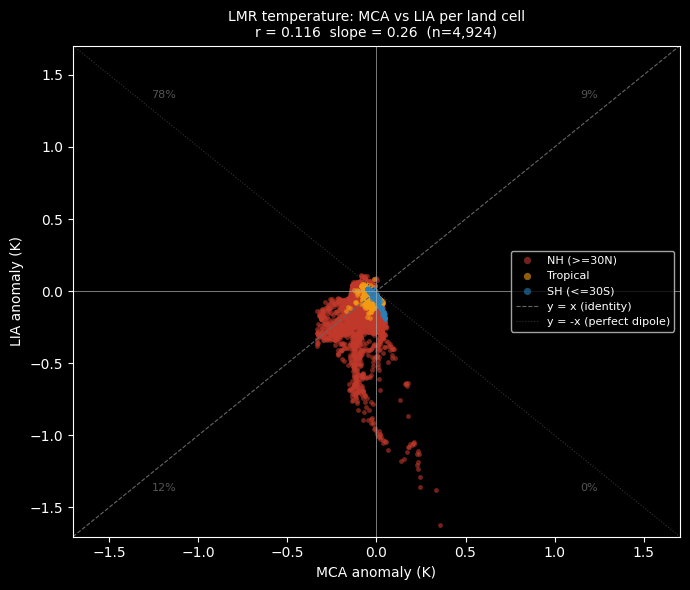

In [7]:
# Cell 7 — LMR temperature MCA vs LIA scatter (per land cell)
# Color by latitude band; reference lines y=x (identity) and y=-x (perfect anticorrelation)

x_vals = mca_air[lmr_land_rows, lmr_land_cols]
y_vals = lia_air[lmr_land_rows, lmr_land_cols]

# Latitude bands
lat_bands = np.where(land_lats >= 30, 'NH (>=30N)',
             np.where(land_lats <= -30, 'SH (<=30S)', 'Tropical'))
band_colors = {'NH (>=30N)': '#c0392b', 'Tropical': '#f39c12', 'SH (<=30S)': '#2980b9'}

fig, ax = plt.subplots(figsize=(7, 6))
for band, color in band_colors.items():
    mask = lat_bands == band
    ax.scatter(x_vals[mask], y_vals[mask], c=color, s=12, alpha=0.6, label=band, linewidths=0)

xy_lim = max(np.abs([x_vals, y_vals]).max() * 1.05, 0.1)
ax.axline((0, 0), slope=1,  color='#666', linewidth=0.8, linestyle='--', label='y = x (identity)')
ax.axline((0, 0), slope=-1, color='#333', linewidth=0.8, linestyle=':',  label='y = -x (perfect dipole)')
ax.axhline(0, color='#aaa', linewidth=0.5)
ax.axvline(0, color='#aaa', linewidth=0.5)
ax.set_xlim(-xy_lim, xy_lim)
ax.set_ylim(-xy_lim, xy_lim)
ax.set_xlabel('MCA anomaly (K)', fontsize=10)
ax.set_ylabel('LIA anomaly (K)', fontsize=10)

r_all, p_all = stats.pearsonr(x_vals, y_vals)
slope, intercept, *_ = stats.linregress(x_vals, y_vals)
ax.set_title(f'LMR temperature: MCA vs LIA per land cell\n'
             f'r = {r_all:.3f}  slope = {slope:.2f}  (n={len(x_vals):,})', fontsize=10)
ax.legend(fontsize=8, markerscale=1.5)

# Annotate quadrant percentages
q_counts = {
    'Q1 (MCA+, LIA+)': ((x_vals > 0) & (y_vals > 0)).sum(),
    'Q2 (MCA-, LIA+)': ((x_vals < 0) & (y_vals > 0)).sum(),
    'Q3 (MCA-, LIA-)': ((x_vals < 0) & (y_vals < 0)).sum(),
    'Q4 (MCA+, LIA-)': ((x_vals > 0) & (y_vals < 0)).sum(),
}
for (q, n), (dx, dy) in zip(q_counts.items(), [(1,-1),(-1,-1),(-1,1),(1,1)]):
    ax.annotate(f'{n/len(x_vals)*100:.0f}%',
                xy=(dx * xy_lim * 0.7, dy * xy_lim * 0.8),
                ha='center', va='center', fontsize=8, color='#555')

plt.tight_layout()
plt.savefig(OUT_DIR / 'bt4c_lmr_temp_scatter.png', dpi=150, bbox_inches='tight')
print('Saved bt4c_lmr_temp_scatter.png')
print(f'Quadrant counts: {q_counts}')
print(f'r = {r_all:.3f}  slope = {slope:.3f}  p = {p_all:.4e}')

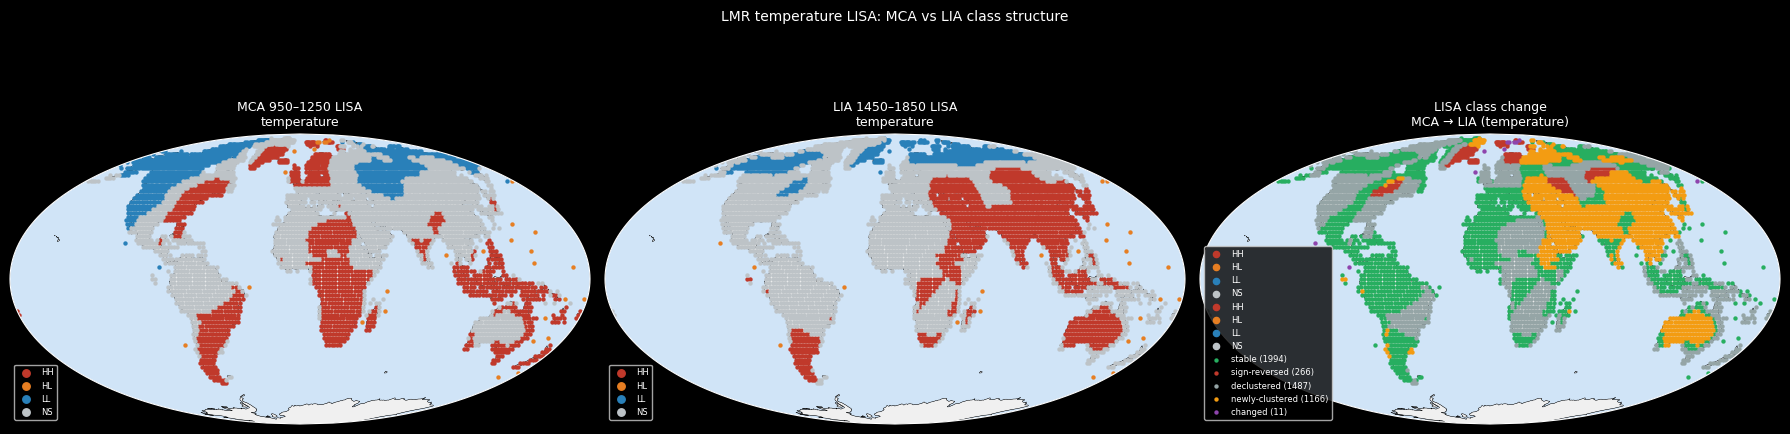

In [8]:
# Cell 8 — LMR LISA cross-epoch: MCA vs LIA temperature class comparison
# Merge per-cell LISA classifications; cross-tab transitions; side-by-side maps + change map

# Build comparison dataframe keyed on cell_id (flat index into 91x180 grid)
comp = mca_lisa_air[['lat','lon','lisa_class']].rename(columns={'lisa_class':'mca_class'})
comp = comp.join(lia_lisa_air[['lisa_class']].rename(columns={'lisa_class':'lia_class'}))
comp = comp.dropna(subset=['mca_class','lia_class'])

# Cross-tabulation
ct = pd.crosstab(comp['mca_class'], comp['lia_class'],
                 rownames=['MCA class'], colnames=['LIA class'])
print('LISA class transition table (temperature):')
print(ct.to_string())

# Change category
def change_cat(row):
    m, l = row['mca_class'], row['lia_class']
    if m == l:         return 'stable'
    if {m,l} == {'HH','LL'}: return 'sign-reversed'
    if l == 'NS':      return 'declustered'
    if m == 'NS':      return 'newly-clustered'
    return 'changed'

comp['change'] = comp.apply(change_cat, axis=1)
print('\nTransition category counts:')
print(comp['change'].value_counts().to_string())

# Maps: 3-panel (MCA class | LIA class | change)
CLASSES = ['HH','HL','LH','LL','NS']
CHANGE_COLORS = {'stable':'#27ae60', 'sign-reversed':'#c0392b',
                 'declustered':'#95a5a6', 'newly-clustered':'#f39c12', 'changed':'#8e44ad'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                         subplot_kw={'projection': ccrs.Mollweide()})

def plot_lisa_classes(ax, lisa_sub, title):
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='#d0e4f7', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3, zorder=1)
    for cls in CLASSES:
        sub = lisa_sub[lisa_sub['lisa_class'] == cls]
        if len(sub):
            lons_p = np.where(sub['lon'].values >= 180, sub['lon'].values - 360, sub['lon'].values)
            ax.scatter(lons_p, sub['lat'].values,
                       c=LISA_COLORS[cls], s=10, linewidths=0, label=cls,
                       transform=ccrs.PlateCarree(), zorder=2)
    handles = [plt.scatter([],[], c=LISA_COLORS[c], s=20, label=c) for c in CLASSES if c in lisa_sub['lisa_class'].values]
    ax.legend(handles=handles, loc='lower left', fontsize=6, markerscale=1.2)
    ax.set_title(title, fontsize=9)

plot_lisa_classes(axes[0], mca_lisa_air.reset_index(), 'MCA 950\u20131250 LISA\ntemperature')
plot_lisa_classes(axes[1], lia_lisa_air.reset_index(), 'LIA 1450\u20131850 LISA\ntemperature')

# Change map
axes[2].set_global()
axes[2].add_feature(cfeature.LAND, facecolor='#f0f0f0', zorder=0)
axes[2].add_feature(cfeature.OCEAN, facecolor='#d0e4f7', zorder=0)
axes[2].add_feature(cfeature.COASTLINE, linewidth=0.3, zorder=1)
for cat, color in CHANGE_COLORS.items():
    sub = comp[comp['change'] == cat]
    if len(sub):
        lons_p = np.where(sub['lon'].values >= 180, sub['lon'].values - 360, sub['lon'].values)
        axes[2].scatter(lons_p, sub['lat'].values, c=color, s=10, linewidths=0,
                        label=f'{cat} ({len(sub)})', transform=ccrs.PlateCarree(), zorder=2)
axes[2].legend(loc='lower left', fontsize=6)
axes[2].set_title('LISA class change\nMCA \u2192 LIA (temperature)', fontsize=9)

plt.suptitle('LMR temperature LISA: MCA vs LIA class structure', fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'bt4c_lmr_lisa_crossepoch.png', dpi=150, bbox_inches='tight')
print('Saved bt4c_lmr_lisa_crossepoch.png')

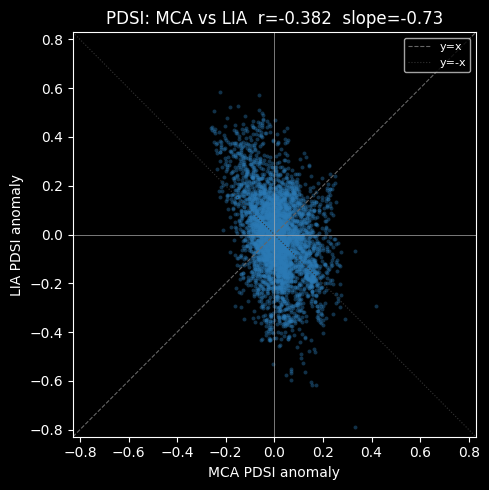

In [9]:
# Cell 9 — LMR PDSI dipole and scatter (compact: 3-panel)

fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                         subplot_kw={'projection': ccrs.Mollweide()})

# Percentile-based scale (same fix as Cell 6)
all_pdsi_vals = np.concatenate([mca_pdsi[land_mask_lmr], lia_pdsi[land_mask_lmr]])
abs_max_p = np.nanpercentile(np.abs(all_pdsi_vals), 98)
abs_max_p = np.ceil(abs_max_p * 10) / 10
print(f'MCA/LIA PDSI color scale: ±{abs_max_p:.2f}  (98th-pct)')

lmr_scatter_map(axes[0], mca_pdsi, 'MCA 950–1250\nPDSI anomaly',
                -abs_max_p, abs_max_p, cmap='BrBG', cbar_label='ΔPDSI')
lmr_scatter_map(axes[1], lia_pdsi, 'LIA 1450–1850\nPDSI anomaly',
                -abs_max_p, abs_max_p, cmap='BrBG', cbar_label='ΔPDSI')

pdsi_sum = mca_pdsi + lia_pdsi
pdsi_dmax = max(np.abs(np.nanpercentile(pdsi_sum[land_mask_lmr], [2, 98])).max(), 0.05)
lmr_scatter_map(axes[2], pdsi_sum,
                'PDSI MCA + LIA sum\n(≈0 = symmetric dipole)',
                -pdsi_dmax, pdsi_dmax, cmap='PuOr', cbar_label='ΔPDSI MCA + LIA')

plt.suptitle('LMR v2.1 PDSI anomaly: MCA, LIA, and dipole asymmetry', fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'bt4c_lmr_pdsi_dipole_maps.png', dpi=150, bbox_inches='tight')
print('Saved bt4c_lmr_pdsi_dipole_maps.png')

# Scatter summary
px = mca_pdsi[lmr_land_rows, lmr_land_cols]
py = lia_pdsi[lmr_land_rows, lmr_land_cols]
r_pdsi = stats.pearsonr(px, py)
slope_p, *_ = stats.linregress(px, py)
pdsi_land_sum = pdsi_sum[land_mask_lmr]
pct_near_zero_p = (np.abs(pdsi_land_sum) < 0.2).mean() * 100
print(f'PDSI dipole sum |x| < 0.2: {pct_near_zero_p:.1f}% of land cells')
print(f'PDSI Pearson r (MCA vs LIA): {r_pdsi.statistic:.3f}  slope={slope_p:.3f}  p={r_pdsi.pvalue:.4e}')

# Scatter plot
fig2, ax2 = plt.subplots(figsize=(5, 5))
ax2.scatter(px, py, s=8, alpha=0.4, color='#2c7bb6', linewidths=0)
xy_lim_p = max(np.abs([px, py]).max() * 1.05, 0.1)
ax2.axline((0,0), slope=1,  color='#666', lw=0.8, ls='--', label='y=x')
ax2.axline((0,0), slope=-1, color='#333', lw=0.8, ls=':',  label='y=-x')
ax2.axhline(0, color='#aaa', lw=0.5); ax2.axvline(0, color='#aaa', lw=0.5)
ax2.set_xlim(-xy_lim_p, xy_lim_p); ax2.set_ylim(-xy_lim_p, xy_lim_p)
ax2.set_xlabel('MCA PDSI anomaly'); ax2.set_ylabel('LIA PDSI anomaly')
ax2.set_title(f'PDSI: MCA vs LIA  r={r_pdsi.statistic:.3f}  slope={slope_p:.2f}')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'bt4c_lmr_pdsi_scatter.png', dpi=150, bbox_inches='tight')
print('Saved bt4c_lmr_pdsi_scatter.png')

In [10]:
# Cell 10 — load HYDE grids from DB (replicates 16b Cell 11)
t0 = _time.time()

HYDE_NROW, HYDE_NCOL = 2160, 4320

crop_cols = ', '.join([f'cropland[{si+1}] AS crop_{si}'  for si, _ in HYDE_NONDEG])
graz_cols = ', '.join([f'grazing[{si+1}]  AS graz_{si}'  for si, _ in HYDE_NONDEG])

conn = db_connect()
hyde_df = pd.read_sql(f"""
    SELECT ST_X(ST_Centroid(geom)) AS lon,
           ST_Y(ST_Centroid(geom)) AS lat,
           area_km2, {crop_cols}, {graz_cols}
    FROM temporal.hyde_cells
""", conn)
conn.close()
print(f'HYDE loaded: {len(hyde_df):,} rows in {_time.time()-t0:.1f}s')

lons_h = hyde_df['lon'].values
lats_h = hyde_df['lat'].values
area_h = hyde_df['area_km2'].values

hyde_row = np.clip(np.round((90.0  - lats_h) * 12).astype(int), 0, HYDE_NROW - 1)
hyde_col = np.clip(np.round((lons_h + 180.0) * 12).astype(int), 0, HYDE_NCOL - 1)

area_raster = np.full((HYDE_NROW, HYDE_NCOL), np.nan, dtype=np.float32)
area_raster[hyde_row, hyde_col] = area_h

hyde_land_rows, hyde_land_cols = np.where(~np.isnan(area_raster))
n_hyde_land = len(hyde_land_rows)

def rasterize_hyde_frac(col_prefix):
    grids = {}
    for si, _ in HYDE_NONDEG:
        vals = np.where(hyde_df[f'{col_prefix}_{si}'].values < 0, 0.0,
                        hyde_df[f'{col_prefix}_{si}'].values).astype(np.float32)
        raster = np.full((HYDE_NROW, HYDE_NCOL), np.nan, dtype=np.float32)
        raster[hyde_row, hyde_col] = vals
        grids[si] = np.clip(raster / area_raster, 0.0, 1.0)
    return grids

crop_grids = rasterize_hyde_frac('crop')
graz_grids = rasterize_hyde_frac('graz')

# Display grid (stride=4 for Mollweide plots: 540x1080)
STRIDE = 4
hlons_disp = np.linspace(-180 + 1/24, 180 - 1/24, HYDE_NCOL)[::STRIDE]
hlats_disp = np.linspace( 90 - 1/24, -90 + 1/24, HYDE_NROW)[::STRIDE]
HLON_D, HLAT_D = np.meshgrid(hlons_disp, hlats_disp)

print(f'HYDE land cells: {n_hyde_land:,}  |  display grid: {HLON_D.shape}  |  rasterization complete')

HYDE land cells: 2,213,836  |  display grid: (540, 1080)  |  rasterization complete


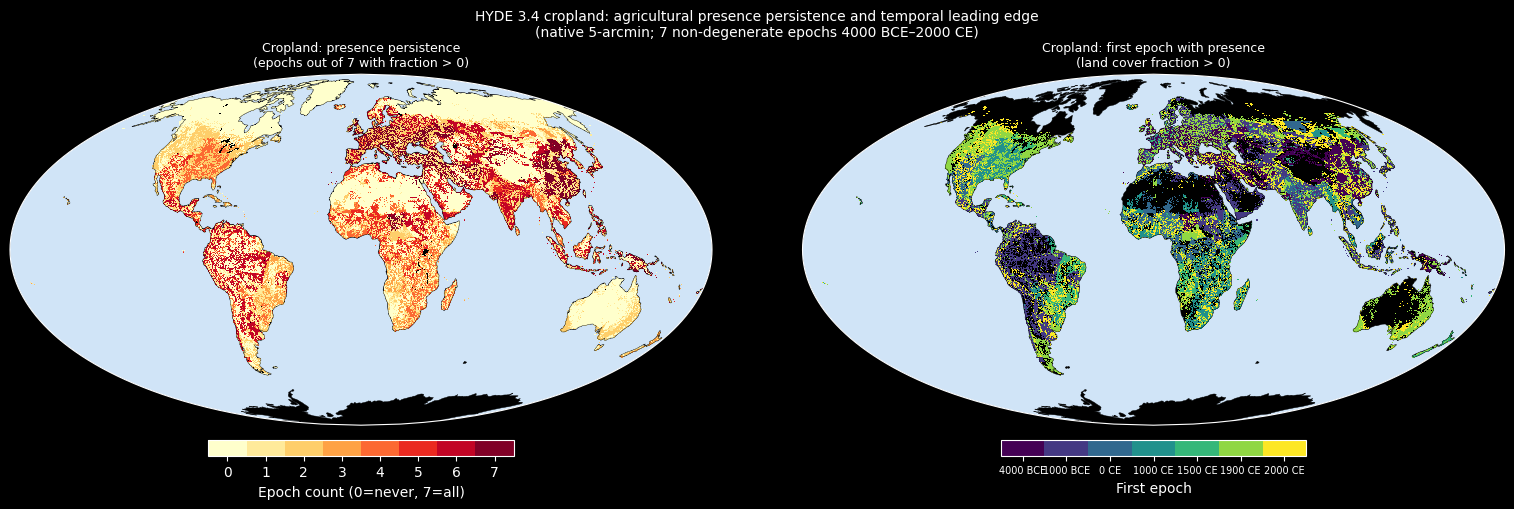

In [11]:
# Cell 11 — HYDE cropland persistence + first-epoch maps
# Persistence: count of N_HYDE_EPOCHS (7) in which fraction > 0 per land cell
# First epoch: index of earliest epoch with fraction > 0 (NaN = never)

def compute_persistence(grids):
    persist = np.zeros(n_hyde_land, dtype=np.int8)
    first   = np.full(n_hyde_land, -1, dtype=np.int8)
    for epoch_i, (si, _) in enumerate(HYDE_NONDEG):
        y = grids[si][hyde_land_rows, hyde_land_cols]
        y = np.nan_to_num(y, nan=0.0)
        present = y > 0
        persist += present.astype(np.int8)
        first[(first == -1) & present] = epoch_i
    return persist, first

crop_persist, crop_first = compute_persistence(crop_grids)
print(f'Cropland persistence computed.  Value counts:\n{pd.Series(crop_persist).value_counts().sort_index().to_string()}')

def vec_to_raster(vec, fill=np.nan):
    r = np.full((HYDE_NROW, HYDE_NCOL), fill, dtype=np.float32)
    r[hyde_land_rows, hyde_land_cols] = vec.astype(np.float32)
    return r

crop_persist_2d = vec_to_raster(crop_persist)
crop_first_2d   = vec_to_raster(np.where(crop_first == -1, np.nan, crop_first))

epoch_labels_short = ['4000\nBCE','1000\nBCE','0 CE','1000\nCE','1500\nCE','1900\nCE','2000\nCE']

fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                         subplot_kw={'projection': ccrs.Mollweide()})

def hyde_pcolormesh(ax, raster_2d, title, cmap, vmin, vmax, cbar_kw=None):
    ax.set_global()
    ax.add_feature(cfeature.OCEAN, facecolor='#d0e4f7', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3, zorder=2)
    disp = raster_2d[::STRIDE, ::STRIDE]
    disp = np.ma.masked_invalid(disp)
    pcm = ax.pcolormesh(HLON_D, HLAT_D, disp,
                        cmap=cmap, vmin=vmin, vmax=vmax,
                        transform=ccrs.PlateCarree(), zorder=1, rasterized=True)
    cb = plt.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.04, fraction=0.04,
                      **(cbar_kw or {}))
    ax.set_title(title, fontsize=9)
    return cb

# Persistence count (0-7)
cmap_p = plt.cm.get_cmap('YlOrRd', 8)
cb1 = hyde_pcolormesh(axes[0], crop_persist_2d,
                      'Cropland: presence persistence\n(epochs out of 7 with fraction > 0)',
                      cmap_p, vmin=-0.5, vmax=7.5)
cb1.set_ticks(range(8))
cb1.set_label('Epoch count (0=never, 7=all)')

# First epoch (0-6 categorical)
cmap_f = plt.cm.get_cmap('viridis', 7)
cb2 = hyde_pcolormesh(axes[1], crop_first_2d,
                      'Cropland: first epoch with presence\n(land cover fraction > 0)',
                      cmap_f, vmin=-0.5, vmax=6.5)
cb2.set_ticks(range(7))
cb2.set_ticklabels([l.replace('\n',' ') for l in epoch_labels_short], fontsize=7)
cb2.set_label('First epoch')

plt.suptitle('HYDE 3.4 cropland: agricultural presence persistence and temporal leading edge\n'
             '(native 5-arcmin; 7 non-degenerate epochs 4000 BCE\u20132000 CE)',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'bt4c_hyde_cropland_persistence.png', dpi=150, bbox_inches='tight')
print('Saved bt4c_hyde_cropland_persistence.png')

# Summary: persistence level distribution
for v in range(8):
    n = int((crop_persist == v).sum())
    print(f'  {v}/7 epochs: {n:>8,} cells ({n/n_hyde_land*100:.2f}%)')

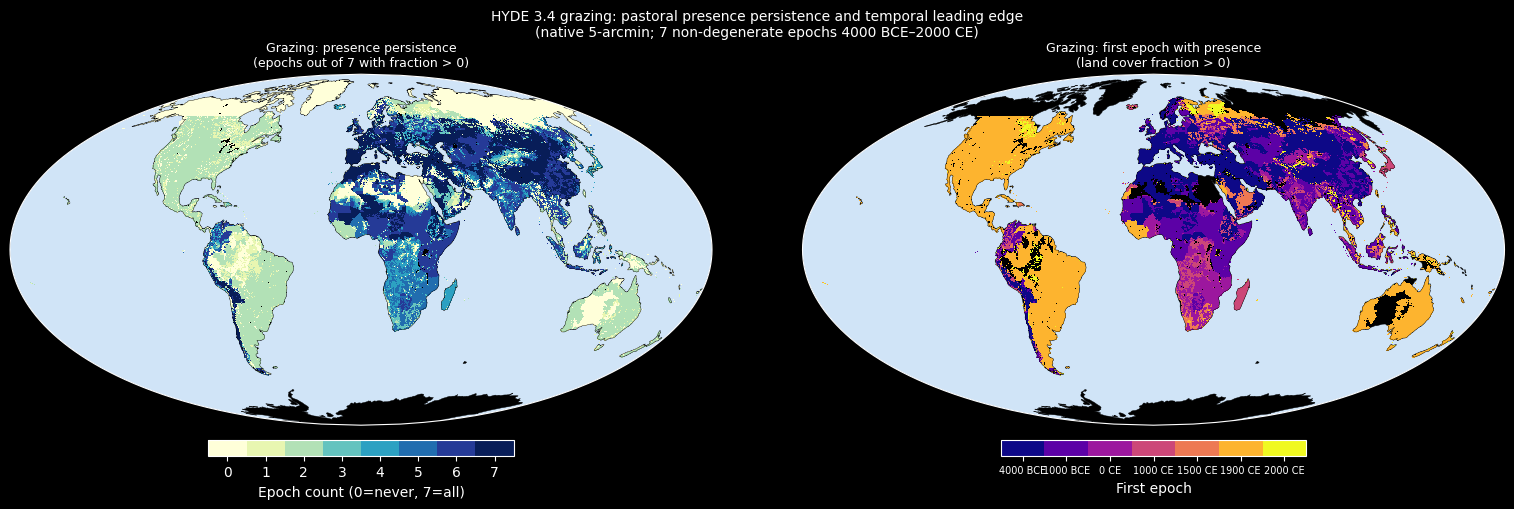

In [12]:
# Cell 12 — HYDE grazing persistence + first-epoch maps

graz_persist, graz_first = compute_persistence(graz_grids)
print(f'Grazing persistence computed.  Value counts:\n{pd.Series(graz_persist).value_counts().sort_index().to_string()}')

graz_persist_2d = vec_to_raster(graz_persist)
graz_first_2d   = vec_to_raster(np.where(graz_first == -1, np.nan, graz_first))

fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                         subplot_kw={'projection': ccrs.Mollweide()})

cb1 = hyde_pcolormesh(axes[0], graz_persist_2d,
                      'Grazing: presence persistence\n(epochs out of 7 with fraction > 0)',
                      plt.cm.get_cmap('YlGnBu', 8), vmin=-0.5, vmax=7.5)
cb1.set_ticks(range(8))
cb1.set_label('Epoch count (0=never, 7=all)')

cb2 = hyde_pcolormesh(axes[1], graz_first_2d,
                      'Grazing: first epoch with presence\n(land cover fraction > 0)',
                      plt.cm.get_cmap('plasma', 7), vmin=-0.5, vmax=6.5)
cb2.set_ticks(range(7))
cb2.set_ticklabels([l.replace('\n',' ') for l in epoch_labels_short], fontsize=7)
cb2.set_label('First epoch')

plt.suptitle('HYDE 3.4 grazing: pastoral presence persistence and temporal leading edge\n'
             '(native 5-arcmin; 7 non-degenerate epochs 4000 BCE\u20132000 CE)',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'bt4c_hyde_grazing_persistence.png', dpi=150, bbox_inches='tight')
print('Saved bt4c_hyde_grazing_persistence.png')

print('\nCropland vs grazing persistence contrast (cells at max persistence, 7/7):')
print(f'  Cropland  7/7: {(crop_persist==7).sum():>8,} ({(crop_persist==7).mean()*100:.2f}%)')
print(f'  Grazing   7/7: {(graz_persist==7).sum():>8,} ({(graz_persist==7).mean()*100:.2f}%)')
print(f'  Cropland  0/7: {(crop_persist==0).sum():>8,} ({(crop_persist==0).mean()*100:.2f}%)')
print(f'  Grazing   0/7: {(graz_persist==0).sum():>8,} ({(graz_persist==0).mean()*100:.2f}%)')

In [ ]:
# Cell 13 — regional zoom maps: native 5-arcmin detail
# 2 rows (cropland top, grazing bottom) x 3 cols (Fertile Crescent, N China Plain, Mesoamerica)
# Uses imshow directly (PlateCarree, regional extent) — shows detail invisible in Mollweide

REGIONS = [
    ('Fertile Crescent / Levant', 30, 50, 25, 40),
    ('North China Plain',         108, 125, 28, 42),
    ('Mesoamerica',               -100, -85, 12, 25),
]
VARIABLES = [
    ('Cropland persistence', crop_persist_2d),
    ('Grazing persistence',  graz_persist_2d),
]

fig, axes = plt.subplots(len(VARIABLES), len(REGIONS), figsize=(16, 8),
                         subplot_kw={'projection': ccrs.PlateCarree()})

cmap_reg = plt.cm.get_cmap('YlOrRd', 8)

for row_i, (var_label, persist_2d) in enumerate(VARIABLES):
    for col_i, (region_name, lon0, lon1, lat0, lat1) in enumerate(REGIONS):
        ax = axes[row_i, col_i]

        col_lo = int(np.round((lon0 + 180) * 12))
        col_hi = int(np.round((lon1 + 180) * 12))
        row_lo = int(np.round((90 - lat1) * 12))
        row_hi = int(np.round((90 - lat0) * 12))
        col_lo = max(0, col_lo); col_hi = min(HYDE_NCOL, col_hi)
        row_lo = max(0, row_lo); row_hi = min(HYDE_NROW, row_hi)

        region_data = np.ma.masked_invalid(persist_2d[row_lo:row_hi, col_lo:col_hi])

        ax.set_extent([lon0, lon1, lat0, lat1], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.OCEAN, facecolor='#d0e4f7', zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':', zorder=2)

        ax.imshow(region_data, origin='upper',
                  extent=[lon0, lon1, lat0, lat1],
                  cmap=cmap_reg, vmin=-0.5, vmax=7.5,
                  transform=ccrs.PlateCarree(), zorder=1,
                  interpolation='nearest')

        if row_i == 0:
            ax.set_title(region_name, fontsize=9, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(var_label, fontsize=10, fontweight='bold')

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='#aaa', alpha=0.5)
        gl.top_labels = False; gl.right_labels = False

cbar_ax = fig.add_axes([0.15, 0.04, 0.70, 0.025])
sm = plt.cm.ScalarMappable(cmap=cmap_reg, norm=mcolors.BoundaryNorm(range(9), cmap_reg.N))
cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cb.set_ticks(range(8))
cb.set_label('Presence persistence (0 = never, 7 = all 7 epochs)', fontsize=9)

plt.suptitle(
    'HYDE 3.4 presence persistence — regional detail (native 5-arcmin)\n'
    'Top row: cropland  |  Bottom row: grazing',
    fontsize=11, y=1.02)
plt.subplots_adjust(bottom=0.10)
plt.savefig(OUT_DIR / 'bt4c_hyde_persistence_regional.png', dpi=150, bbox_inches='tight')
print('Saved bt4c_hyde_persistence_regional.png')

## Findings — Phase 4c

*Paste into `logs/esda_findings.md` under `## Phase 4 CHAR — Band T native-unit characterization`.*

---

### BT4C.1 — LMR temperature: MCA and LIA are not a dipole

**Date**: 2026-05-22
**Notebook**: `16c_band_t_native_cross_temporal.ipynb`
**Method**: Per-cell comparison of MCA (950–1250 CE) and LIA (1450–1850 CE) temperature anomaly fields at 2° land grid (4,924 cells), anomalies relative to full 0–1998 CE mean. Percentile-based color scale (98th pct ≈ ±0.4 K) used for maps; `nanmax` scale was suppressed by Arctic outlier cells.

**Results**:
- Pearson r(MCA, LIA temperature) = **+0.116** (slope = 0.26) — weakly *positive*, not anticorrelated. No dipole.
- A symmetric dipole would give r ≈ −1, slope ≈ −1. This result is close to zero.
- Quadrant breakdown: 78% of land cells have both MCA and LIA **negative** relative to the 0–1998 mean — an artifact of the 20th-century industrial warming inflating the baseline, not a climate signal. Only **9%** show the canonical pattern (MCA positive, LIA negative).
- Spatial variance asymmetry: LIA anomaly spread ≈ 6× MCA anomaly spread (vertical cigar shape in scatter). LIA left a stronger, more coherent spatial imprint in LMR than MCA did.
- Dipole sum (MCA + LIA): positive over much of NH land — the MCA warm signal at those cells exceeds the LIA cooling signal, confirming asymmetry. The model prior damps the weaker, more contested MCA signal more than the LIA signal.

**LMR-as-reanalysis caveat (first-class)**: all values include CCSM4-LME model prior spatial covariance. r = +0.116 and the asymmetry described above are properties of the LMR reanalysis field, not directly of past climate.

---

### BT4C.2 — LMR LISA cross-epoch: spatial cluster structure substantially reorganises MCA → LIA

**Date**: 2026-05-22
**Notebook**: `16c_band_t_native_cross_temporal.ipynb`
**Method**: Per-cell LISA class transition (temperature) from `band_t_native_lmr_lisa.parquet`. n = 4,924 land cells.

**Transition counts** (MCA → LIA):
| Category | Count | % of land cells |
|----------|-------|-----------------|
| Stable (same class) | 1,994 | 40.5% |
| Declustered (→ NS) | 1,487 | 30.2% |
| Newly-clustered (NS →) | 1,166 | 23.7% |
| Sign-reversed (HH ↔ LL) | 266 | 5.4% |
| Other change | 11 | 0.2% |

- Only 40% of cells hold the same LISA class across both periods — the spatial cluster structure is not stable.
- The dominant transition is **declustering**: cells that had significant spatial structure in MCA (mostly the NH LL cool-cluster band) lost significance in LIA. LIA cooling is too spatially uniform in the NH for LISA to identify local cold outliers — neighbours cool together.
- **Sign-reversal is rare (5.4%)**: the spatial geography of warm vs. cool clustering does not simply invert between periods.
- Together with BT4C.1 (r = +0.12), these results confirm that MCA and LIA do not form a symmetric dipole in LMR at the spatial-clustering level either.

---

### BT4C.3 — LMR PDSI: partial dipole between MCA and LIA

**Date**: 2026-05-22
**Notebook**: `16c_band_t_native_cross_temporal.ipynb`
**Method**: Same as BT4C.1 for PDSI anomaly.

**Results**:
- Pearson r(MCA, LIA PDSI) = **−0.382** (slope = −0.73) — genuinely anticorrelated. A partial dipole.
- Scatter cloud is roughly circular: MCA and LIA PDSI anomaly variance are comparable (contrast with temperature where LIA >> MCA).
- Slope −0.73: the anticorrelation is real but not perfect (a clean dipole would give slope ≈ −1).

**Contrast with temperature**: PDSI r = −0.382 vs. temperature r = +0.116. Moisture geography reorganised more coherently between MCA and LIA than thermal geography did. This reflects the physical difference: temperature in LMR is dominated by large-scale model-prior smoothing; PDSI reflects local moisture balance driven by circulation patterns (monsoon, ENSO, NAO) that can genuinely reverse between climate regimes.

**Implication**: for EDOPS Band T, LMR climate anomalies at a specific query location carry more interpretable period-to-period moisture information than temperature information. Temperature anomalies at 2° resolution are structurally near-identical across MCA and LIA; PDSI anomalies are meaningfully different.

---

### BT4C.4 — HYDE cropland: presence persistence and agricultural leading edge

**Date**: 2026-05-22
**Notebook**: `16c_band_t_native_cross_temporal.ipynb`
**Method**: Per 5-arcmin land cell, count of 7 non-degenerate epochs (4000 BCE–2000 CE) with cropland fraction > 0. First-epoch map: earliest epoch with presence. n = 2,213,836 land cells. *Presence persistence ≠ cluster-core persistence; HH LISA was intractable — see BT4B.2.*

**Persistence distribution**:

| Epochs present | Cells | % |
|---|---|---|
| 0/7 (never farmed) | 1,075,208 | 48.57% |
| 1/7 | 223,915 | 10.11% |
| 2/7 | 303,954 | 13.73% |
| 3/7 | 63,430 | 2.87% |
| 4/7 | 126,097 | 5.70% |
| 5/7 | 108,568 | 4.90% |
| 6/7 | 190,375 | 8.60% |
| 7/7 (all epochs) | 122,289 | 5.52% |

**Key patterns**:
- 7/7 cores (farmed all 7 epochs, 5.52% of land): narrow but continuous corridors along the Fertile Crescent and Levant, Nile Valley, Ganges-Indus plain, North China Plain — the canonical Neolithic agricultural origins. River-valley alignment is clearly visible at native 5-arcmin in the regional zoom.
- Nearly half of land cells (48.57%) show zero cropland presence across all 7 epochs — Himalayas, Sahara, Australian outback, boreal zones. Not missing data; genuinely uncultivated in HYDE's reconstruction.
- First-epoch map: darkest viridis (4000 BCE) concentrated at those same 7/7 cores; gradient diffuses outward. Consistent with an agricultural diffusion pattern, though HYDE derives this from population estimates rather than direct archaeological evidence.
- Americas: almost entirely late (1500–2000 CE first epoch). The Old World / New World contrast is the sharpest visual signal in the maps.
- **Black = never farmed**: cells with crop_first == −1 (NaN) render as transparent against dark figure background. Distinct from 4000 BCE cells, which appear as darkest viridis.

**HYDE methodology caveat**: spatial allocation uses environmental suitability, making HYDE land use *not independent* of EDOPS environmental variables. Any downstream correspondence test between EDOPS signatures and HYDE cropland must acknowledge this circularity.

---

### BT4C.5 — HYDE grazing: pastoral persistence and cropland contrast

**Date**: 2026-05-22
**Notebook**: `16c_band_t_native_cross_temporal.ipynb`

**Persistence distribution**:

| Epochs present | Cells | % |
|---|---|---|
| 0/7 (no grazing) | 657,073 | 29.68% |
| 1/7 | 132,922 | 6.00% |
| 2/7 | 505,558 | 22.84% |
| 3/7 | 63,135 | 2.85% |
| 4/7 | 94,679 | 4.28% |
| 5/7 | 144,058 | 6.51% |
| 6/7 | 275,999 | 12.47% |
| 7/7 (all epochs) | 340,412 | 15.38% |

**Key patterns**:
- Grazing spatial extent is vastly larger than cropland: 15.38% of land cells show 7/7 grazing persistence vs. 5.52% for cropland. The entire Old World grassland/savanna/steppe belt (Central Asia, Arabia, sub-Saharan Africa, South Asia) shows 7/7 persistence. Pastoral land use follows biome structure (BT4B.3 confirmed: grazing I ≈ 0.91 even at 4000 BCE).
- Only 29.68% of cells are grazing-free across all epochs (vs. 48.57% for cropland) — pastoralism occupies a much larger portion of the land surface than cultivation.
- First-epoch map: most of Eurasia and Africa is 4000 BCE (darkest) — the pastoral belt was effectively fully established at our earliest HYDE epoch.
- **Americas grazing**: overwhelmingly orange to yellow (1500–2000 CE) — a clean cartographic signature of the Columbian Exchange. Indigenous pre-contact Americas had negligible livestock in HYDE's model.
- **Mesoamerica contrast** (Cell 13 regional zoom): cropland shows substantial persistence (indigenous agriculture pre-dates contact); grazing shows near-zero persistence (no livestock pre-contact). The two variables tell directly opposing historical stories at this region.
- Grazing first-epoch map over Africa and Asia is consistent with reading as a **diffusion map** of pastoral spread from early centres, with the important caveat that HYDE derives this from population/suitability models, not direct archaeological tracking of pastoral diffusion.

---

### BT4C.6 — Phase 4c: paper-figure assessment

**Date**: 2026-05-22
**Notebook**: `16c_band_t_native_cross_temporal.ipynb`

**Assessment**:

- **PDSI scatter (Cell 9)**: the most surprising result of 4c — moisture geography shows a partial dipole (r = −0.38) while temperature does not (r = +0.12). This is a reportable finding about LMR's period structure with a clear physical interpretation. Candidate as a supplementary figure in a methods/characterization paper.

- **HYDE cropland persistence map (Cell 11)**: the most visually readable output of the entire CHAR phase. The 7/7 cores, the first-epoch gradient, and the Old World / New World contrast are all historically intelligible without statistical explanation. Paper-figure candidate, with HYDE methodology caveat.

- **Mesoamerica cropland vs. grazing contrast (Cell 13)**: the side-by-side regional zoom showing indigenous agriculture (cropland) vs. Columbian Exchange livestock (grazing) in the same region is the sharpest single illustration of what the two HYDE variables mean historically. Worth keeping as a standalone inset.

- **LMR temperature results (Cells 6–8)**: characterization, not finding. The non-dipole result and LISA reorganisation are expected given what was known about LMR methodology (model prior, proxy network bias). Worth documenting but not paper-figure level.

**Overall**: 4c produced two reportable findings (PDSI partial dipole; HYDE Old World/New World cropland-vs-grazing contrast) and confirmed expected characterization results for LMR temperature. The Phase 4 CHAR record is complete.